# <center>📊🔍 A Diagnostics Package for Multiple Imputation by Chained Equations (using PMM)</center>

In [1]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# MICE Imputation with PMM & Diagnostics 

In [2]:
def mice_and_diagnostics(df, imputed_cols, auxiliary_cols, m_datasets=10, burnin=10,
                          knn=5, seed=1234, weight_var='TOTWGT', plot_diagnostics=True,
                          label="Dataset", predictor_map=None):
    """
    MICE with genuine PMM (Bayesian regression + nearest-neighbor donor matching,
    sklearn-only -- no lightgbm/miceforest/autoimpute dependency), plus Rubin's Rules 
    pooling diagnostics (FMI, RVI, RE), Von Hippel recommended-M (recommended minimum 
    number of imputations), trace plots, and observed-vs-imputed distributions.
    Note: To find Von Hippel recommended-M, first run a pilot imputation with m_datasets=10,
    then replace the number of imputations (m_datasets) with recommended-M (make a 
    conservative decision, the largest M of vars), given satisfactory diagnostics.

    Args:
        df (pd.DataFrame): Input DataFrame containing both the
            variables to be imputed and their predictors. 
        imputed_cols (str): Variables with missing values to impute via
            MICE + PMM. Every variable here also acts as a predictor for every
            other variable in this list, unless overridden in predictor_map.
        auxiliary_cols (str): Variables used as predictors alongside imputed_cols in 
            the chained-equations regressions. These are never themselves imputed, 
            only used to help predict the variables in imputed_cols.
        m_datasets (int): Number of independent parallel imputation chains
            (m) to run, each seeded from its own child RNG stream. Drives
            the between-imputation variance (B) used in Rubin's Rules and
            the FMI/recommended-M diagnostics (not to be confused with
            burnin, which controls iterations within a single chain).
        burnin (int): Number of full fully-conditional-specification (FCS)
            cycles run within each chain before that chain's dataset is
            finalized. Each cycle updates every variable in imputed_cols
            once, in sequence, conditional on the current state of all
            others. 
        knn (int): Number of nearest observed-prediction neighbors PMM
            considers as the donor pool for each missing case; one donor is
            drawn at random from these knn candidates. Smaller knn tightens
            the donor pool (less blending across distinct subgroups/modes,
            but less variability); larger knn broadens it.
        seed (int): Seed for the root SeedSequence, spawned into m_datasets
            independent per-chain RNG streams so chains are statistically
            independent draws, as required by Rubin's combining rules.
        weight_var (str): Name of the survey design weight column, if given. 
            Used only to compute the population-weighted statistics and inferences 
            (not incorporated into the imputation regressions themselves). To 
            weight the imputation regressions directly, beta_hat and Xt_X_inv would 
            need to be recomputed as weighted least squares (X'WX)^-1 X'WY, with W 
            a diagonal matrix of weight_var values, rather than plain OLS.
        plot_diagnostics (bool): If True, generates MCMC convergence trace
            plots (one per imputed variable, across all chains) and
            observed-vs-imputed KDE density plots (from chain 0 only).
        label (str): Descriptive label (e.g. dataset name) used in
            printed diagnostic table headers and the before/after margins
            output, to distinguish runs when calling this function across
            multiple countries.
        predictor_map (dict, optional): Maps a target variable name to a
            custom list of predictor columns for its regression, overriding
            the default. Any variable in imputed_cols not given a key here
            falls back to "predict from every other variable in
            imputed_cols + auxiliary_cols" (the inclusive strategy).
    """

    N = len(df)
    all_cols = imputed_cols + auxiliary_cols
    missing_masks = {col: df[col].isna() for col in imputed_cols} # locating where the missing values are

    imputed_list = []
    trace_data = []

    print(f"Running {m_datasets} independent MICE chains...")

    root_seq = np.random.SeedSequence(seed) 
    child_seeds = root_seq.spawn(m_datasets) # generates random  independent chains

    for m in range(m_datasets): 
        rng = np.random.default_rng(child_seeds[m])
        current_df = df[all_cols].copy().astype(float)

        # random draw from observed values as a starting point: stochastic hot-deck initialization
        for col in imputed_cols:
            observed_vals = current_df[col].dropna().values
            if len(observed_vals) > 0:
                nan_count = missing_masks[col].sum()
                current_df.loc[missing_masks[col], col] = rng.choice(observed_vals, size=nan_count, replace=True)

        # chained-equations loop (FCS): Bayesian regression draw + PMM donor matching
        for iteration in range(burnin):
            for target in imputed_cols:
                predictors = predictor_map.get(target, [c for c in all_cols if c != target]) if predictor_map else [c for c in all_cols if c != target]
                obs_mask = ~missing_masks[target]
                mis_mask = missing_masks[target]

                n_obs = obs_mask.sum()
                if mis_mask.sum() == 0 or n_obs <= len(predictors) + 1:
                    continue

                X_obs = current_df.loc[obs_mask, predictors].values
                Y_obs = current_df.loc[obs_mask, target].values
                X_mis = current_df.loc[mis_mask, predictors].values

                #Injecting the intercept column (for linear regression)
                X_obs_w_int = np.hstack([np.ones((n_obs, 1)), X_obs])
                X_mis_w_int = np.hstack([np.ones((X_mis.shape[0], 1)), X_mis])
                q_deg = X_obs_w_int.shape[1] # total degrees of freeedom

                # OLS point estimate 
                Xt_X_inv = np.linalg.inv(X_obs_w_int.T @ X_obs_w_int)
                beta_hat = Xt_X_inv @ (X_obs_w_int.T @ Y_obs)
                residuals = Y_obs - (X_obs_w_int @ beta_hat)
                s_sq = np.sum(residuals ** 2) / (n_obs - q_deg) # residual variance

                # Bayesian posterior draws:
                # Ref: van Buuren (2018), Flexible Imputation of Missing Data (2nd ed.), Ch. 3.2.1
                # and Rubin (1987, p. 167)
                # Note: NumPy uses an SVD-based factor by default, not Cholesky specifically, 
                # but any valid square root gives the identical distribution for beta_star
                gamma_draw = rng.gamma(shape=(n_obs - q_deg) / 2.0, scale=2.0)
                sigma_sq_star = ((n_obs - q_deg) * s_sq) / gamma_draw
                covariance_matrix = sigma_sq_star * Xt_X_inv
                beta_star = rng.multivariate_normal(beta_hat, covariance_matrix)

                # PMM (Type 1 matching: the same used in R package). 
                # https://www.rdocumentation.org/packages/mice/versions/3.16.0/topics/mice.impute.pmm
                pred_obs = (X_obs_w_int @ beta_hat).reshape(-1, 1) # y_hat_obs = X_obs * beta_hat
                pred_mis = (X_mis_w_int @ beta_star).reshape(-1, 1)  # bayesian predictions for missing rows

                nn = NearestNeighbors(n_neighbors=knn, algorithm='brute')
                nn.fit(pred_obs)
                distances, indices = nn.kneighbors(pred_mis)
                donor_choices = np.array([rng.choice(idx) for idx in indices])

                observed_indices = current_df.index[obs_mask]
                chosen_real_indices = observed_indices[donor_choices]
                current_df.loc[mis_mask, target] = current_df.loc[chosen_real_indices, target].values

                trace_data.append({
                    'Chain': m + 1,
                    'Iteration': iteration + 1,
                    'Variable': target,
                    'Mean': current_df[target].mean()
                })

        imputed_list.append(current_df)

    # === Pool Diagnostics (Rubin's Rules) ===
    # Q_bar/W_bar/B/T/RIV/df/FMI/RE all match Rubin, D. B. (1987), also
    # laid out in van Buuren (2018)
    # NOTE: within-imputation variance here is the standard-error-of-
    # the-mean approximation under simple random sampling. It doesn't account
    # for survey weights or clustered design -- treat RVI/FMI/
    # recommended M as imputation-quality checks, not design-consistent SEs.
    # Use calculate_weighted_means_with_se (JRR-based) for reportable SEs.
    diagnostics = {}
    for col in imputed_cols:
        means_m = np.array([df_m[col].mean() for df_m in imputed_list])
        vars_m = np.array([df_m[col].var() / N for df_m in imputed_list])

        Q_bar = np.mean(means_m)
        W_bar = np.mean(vars_m) # within-imputation variance

        B = np.sum((means_m - Q_bar) ** 2) / (m_datasets - 1) # between imputation variance
        T = W_bar + (1 + (1 / m_datasets)) * B

        rvi = (1 + (1 / m_datasets)) * B / W_bar if W_bar > 0 else 0
        # v_m uses Rubin's (1987) large-sample df formula. This is the correct
        # choice specifically for deciding how many imputations to run --
        # von Hippel (2020) explicitly notes the small-sample version
        # "should not be used to choose the number of imputations M" (fn. 9, p. 13).
        v_m = (m_datasets - 1) * (1 + (1 / rvi)) ** 2 if rvi > 0 else 9999
        fmi = (rvi + (2 / (v_m + 3))) / (1 + rvi) if rvi > 0 else 0
        relative_efficiency = 1 / (1 + (fmi / m_datasets))

        # Von Hippel's (2020) two-stage procedure: use the upper bound of a 95%
        # CI for the fraction of missing information (not the point estimate)
        # as a conservative input to the "how many imputations" calculation.
        # CI built on the logit scale: logit(fmi) +/- z*sqrt(2/M), citing
        # Harel, O. (2007), in page 4.
        logit_fmi = np.log(fmi / (1 - fmi)) if 0 < fmi < 1 else 0
        se_logit = np.sqrt(2 / m_datasets)
        ci_upper_logit = logit_fmi + 1.96 * se_logit
        fmi_upper = 1 / (1 + np.exp(-ci_upper_logit)) if ci_upper_logit != 0 else fmi

        # Quadratic rule (von Hippel 2020, eq. 1 & 10) targeting CV(SE)=0.05
        gamma = fmi_upper
        m_needed = int(np.ceil(1 + 0.5 * (gamma / 0.05) ** 2)) if gamma > 0 else m_datasets

        diagnostics[col] = {
            'RVI': rvi, 'FMI': fmi, 'Rel Efficiency': relative_efficiency,
            'Current M': m_datasets, 'Recommended M': max(m_needed, 5)
        }

    trace_df = pd.DataFrame(trace_data)
    diagnostic_table = pd.DataFrame.from_dict(diagnostics, orient='index')
    print(diagnostic_table.to_string(float_format=lambda x: f"{x:.4f}"))

    # === PLOTTING (unchanged) ===
    if plot_diagnostics:
        print("\n[Diagnostic 1/2] Generating MCMC Convergence Trace Plots...")
        for target_var in imputed_cols:
            plt.figure(figsize=(10, 2.5))
            var_data = trace_df[trace_df['Variable'] == target_var]
            sns.lineplot(data=var_data, x='Iteration', y='Mean', hue='Chain', palette='tab10', linewidth=1.5, alpha=0.8, legend=False)
            plt.title(f"MCMC Convergence History: {target_var}", fontsize=11, fontweight='bold')
            plt.xlabel("Iteration Cycle", fontsize=9)
            plt.ylabel("Imputed Vector Mean", fontsize=9)
            plt.xticks(ticks=sorted(var_data['Iteration'].unique()))
            plt.grid(True, linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.show()

        print("\n[Diagnostic 2/2] Compiling Distributional Plausibility Subplot Matrix...")
        num_vars = len(imputed_cols)
        cols_grid = 2
        rows_grid = int(np.ceil(num_vars / cols_grid))

        fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(14, 3.5 * rows_grid))
        axes = axes.flatten()

        for idx, target_var in enumerate(imputed_cols):
            ax = axes[idx]
            observed_vals = df[target_var].dropna()
            mis_mask = missing_masks[target_var]
            imputed_vals = imputed_list[0].loc[mis_mask, target_var]

            if len(observed_vals) > 0:
                sns.kdeplot(observed_vals, ax=ax, label="Observed", color="#1f77b4", linewidth=2, fill=True, alpha=0.1)
            if len(imputed_vals) > 0:
                sns.kdeplot(imputed_vals, ax=ax, label="PMM Imputed (M=1)", color="#ff7f0e", linewidth=2, linestyle="--")

            ax.set_title(f"Distribution Profile: {target_var}", fontsize=10, fontweight='bold')
            ax.set_xlabel("")
            ax.set_ylabel("Density")
            ax.grid(True, linestyle='--', alpha=0.3)

        for blank_idx in range(num_vars, len(axes)):
            fig.delaxes(axes[blank_idx])

        plt.suptitle("Observed vs. PMM Imputed Value Distributions Across Variables", fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    # === BEFORE / AFTER WEIGHTED MARGINS ===
    print("="*20, f"{label}: BEFORE IMPUTATION SURVEY MARGINS", "="*20)
    before_means = (df[imputed_cols].multiply(df[weight_var], axis=0).sum()) / \
                   (df[imputed_cols].notna().multiply(df[weight_var], axis=0).sum())
    print(before_means.to_frame(name='Raw Weighted Mean (Observed)'), "\n" + "="*80)

    print("\n" + "="*20, f"{label}: AFTER IMPUTATION POOLED SURVEY MARGINS", "="*20)
    weights_vector = df[weight_var].fillna(1.0).values
    weights_sum = weights_vector.sum()

    after_means = pd.DataFrame([
        (df_m[imputed_cols].multiply(weights_vector, axis=0).sum()) / weights_sum
        for df_m in imputed_list
    ]).mean()

    print(after_means.to_frame(name='Pooled Weighted Mean (Rubin Grand Average)'), "\n" + "="*80)

    return imputed_list, trace_df, diagnostic_table

## An Example for Performing MICE Imputation with Diagnostics
  
Multiple imputation by Chained Equations require the missing data pattern to be at least missing-at-random (MAR). Data cleaning and management steps should be completed before running this function. For detailed explanations, refer to van Buuren, S. (2018). Flexible Imputation of Missing Data (2nd ed.). Chapman & Hall/CRC

In [3]:
# Load the dataset (TIMSS Dataset - Sweden 8th grade data)
sweden_df = pd.read_parquet('sweden_df.parquet')

# Variables/Features
# Specifying variables to be imputed
imputed_variables = [
    'ses_2023', 'ses_2024', 
    'mathshortage_2023', 'mathshortage_2024',
    'schemphsuccess_2023', 'schemphsuccess_2024', 
    'digseff_2023', 'digseff_2024',
    'stud_expect_2023', 'stud_expect_2024', 
    'confidentmath_2023', 'confidentmath_2024',
    'instrclarity_2023', 'instrclarity_2024'
]
# School-level math achievement as auxiliary variables
sweden_df['school_math_mean23'] = sweden_df.groupby('IDSCHOOL')['math1_2023'].transform('mean')
sweden_df['school_math_mean24'] = sweden_df.groupby('IDSCHOOL')['math1_2024'].transform('mean')

# Auxiliary variables to help predict missingness
auxiliary_vars = [
    'math1_2023', 'math1_2024', 'school_math_mean23', 'school_math_mean24'
]


Running 10 independent MICE chains...
                       RVI    FMI  Rel Efficiency  Current M  Recommended M
ses_2023            0.0764 0.0720          0.9929         10              6
ses_2024            0.0696 0.0660          0.9934         10              6
mathshortage_2023   0.0172 0.0170          0.9983         10              5
mathshortage_2024   0.0414 0.0401          0.9960         10              5
schemphsuccess_2023 0.0219 0.0216          0.9978         10              5
schemphsuccess_2024 0.0250 0.0245          0.9976         10              5
digseff_2023        0.0947 0.0880          0.9913         10              9
digseff_2024        0.3450 0.2671          0.9740         10             45
stud_expect_2023    0.0390 0.0378          0.9962         10              5
stud_expect_2024    0.1002 0.0928          0.9908         10              9
confidentmath_2023  0.1309 0.1184          0.9883         10             13
confidentmath_2024  0.1733 0.1518          0.9850 

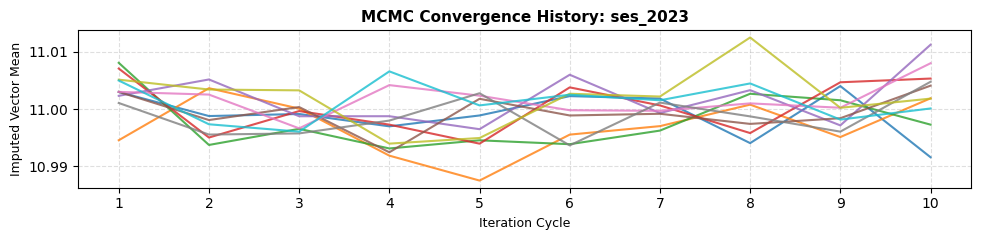

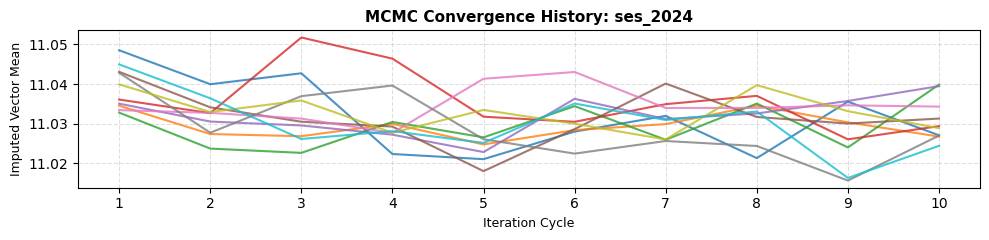

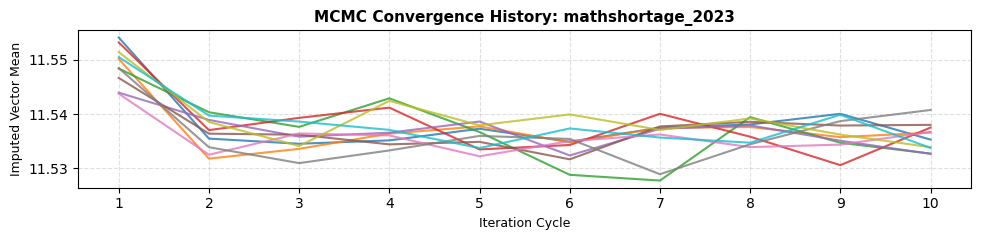

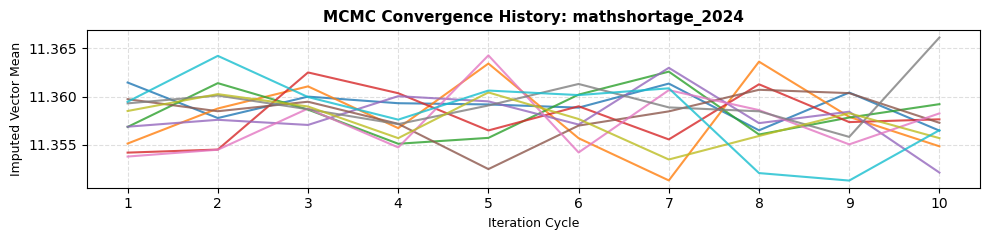

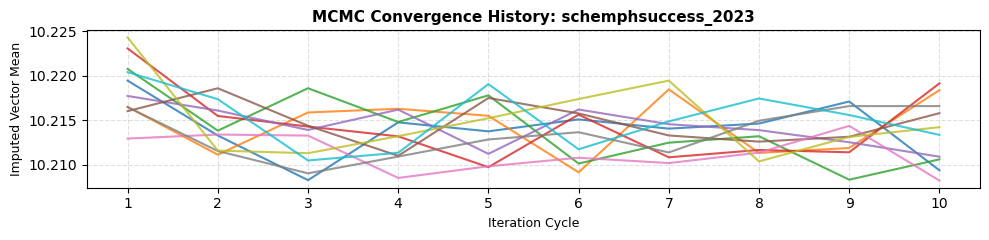

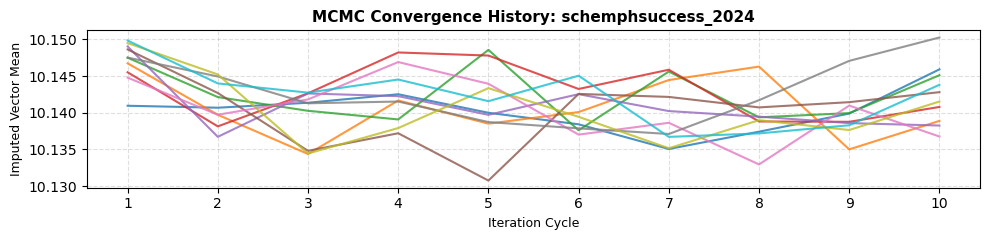

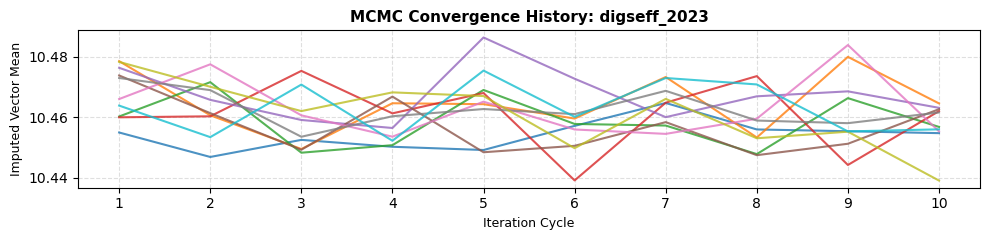

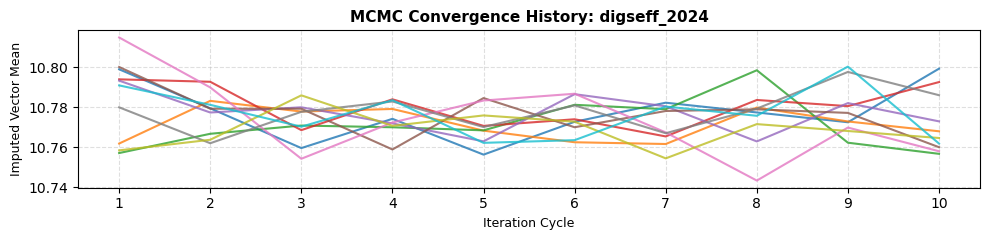

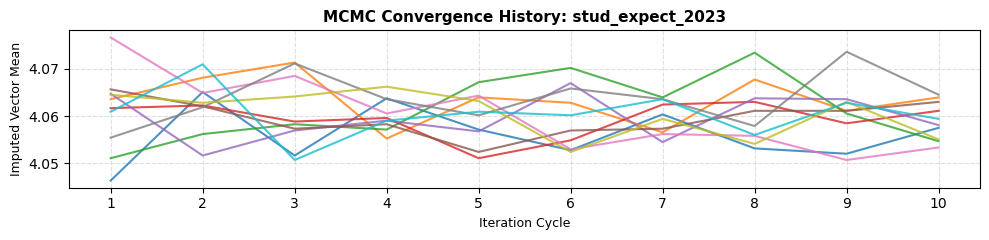

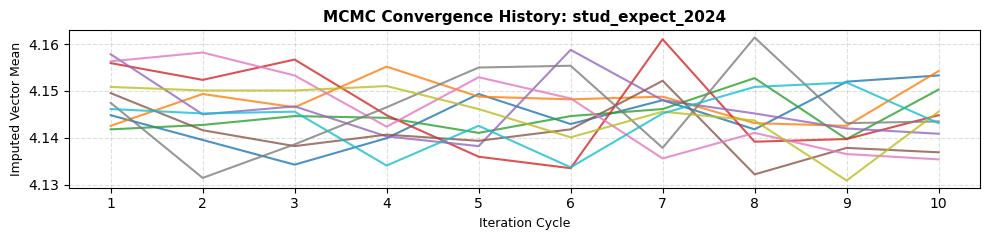

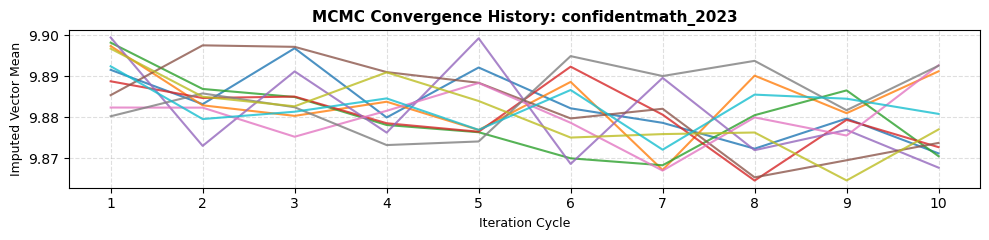

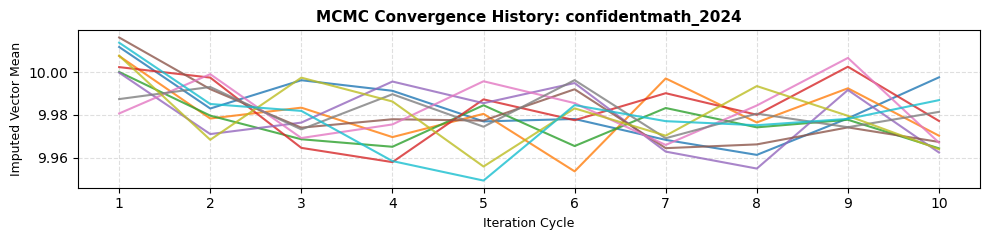

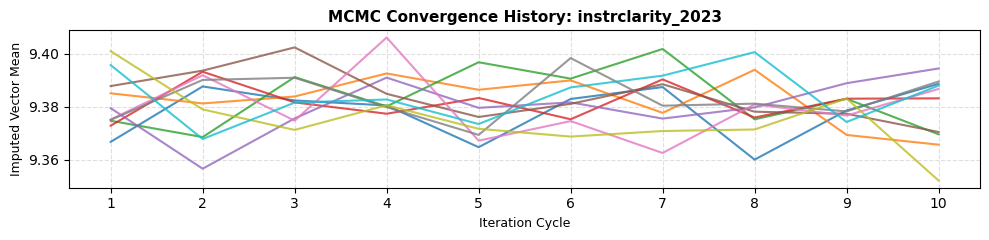

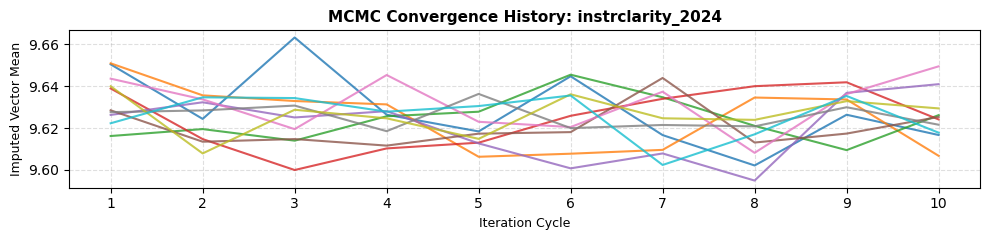


[Diagnostic 2/2] Compiling Distributional Plausibility Subplot Matrix...


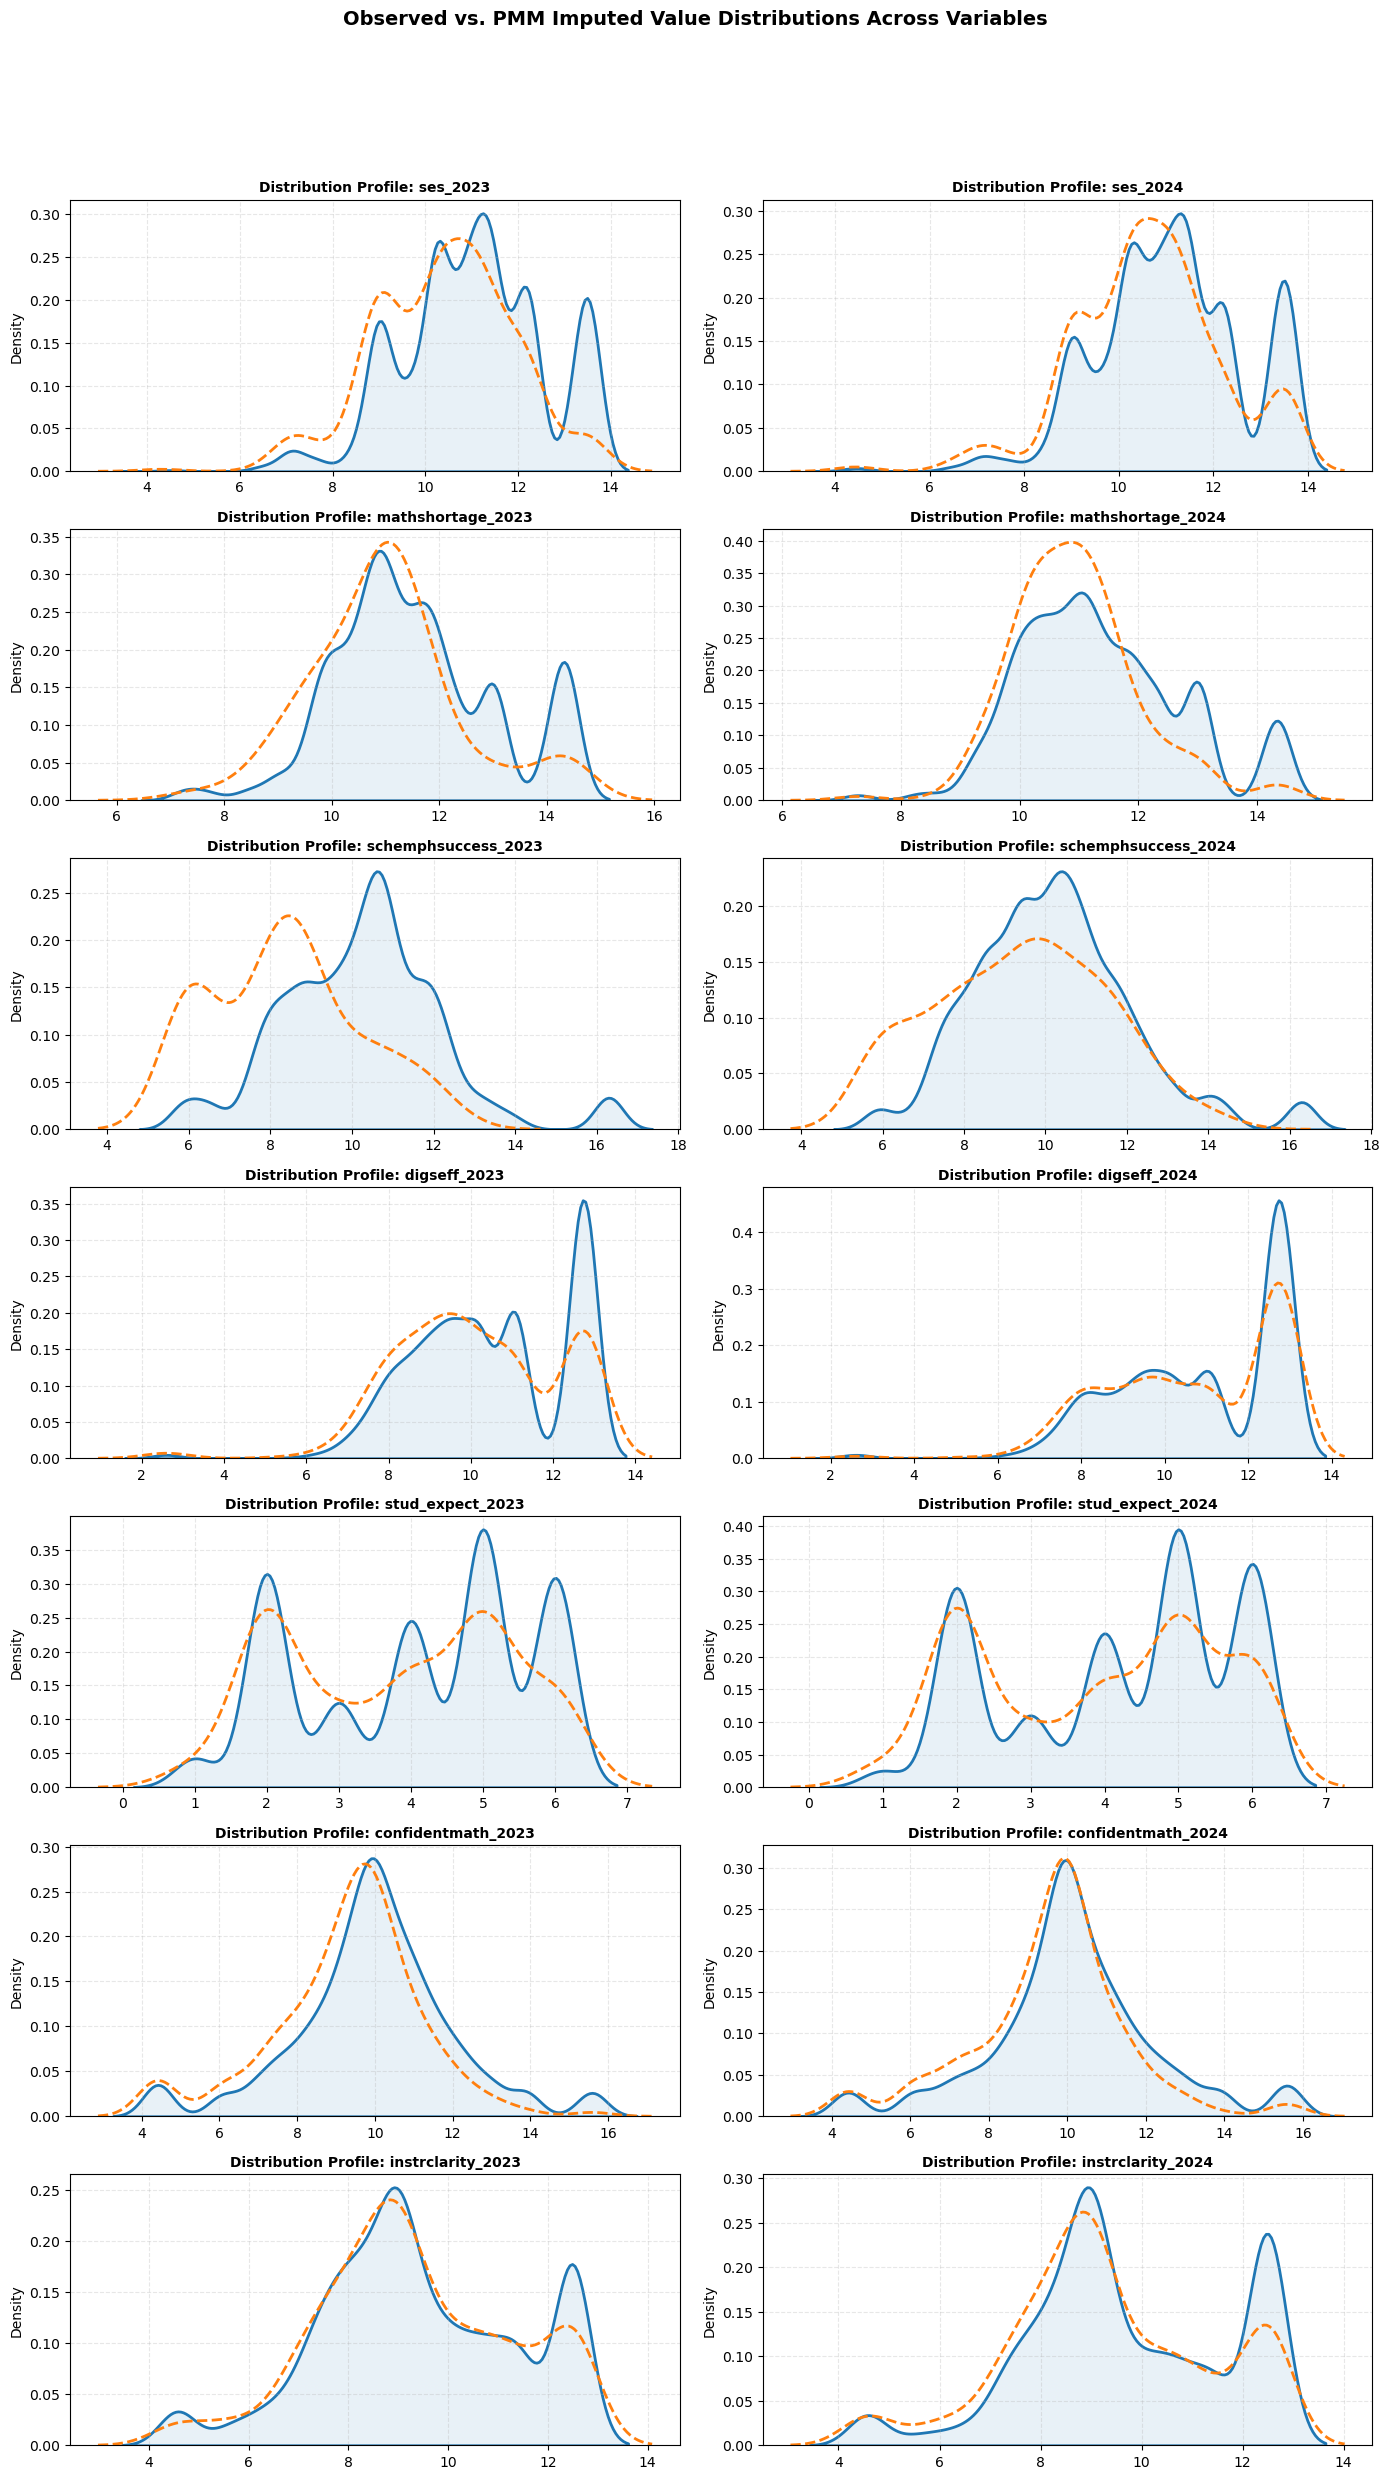

==================== Dataset: BEFORE IMPUTATION SURVEY MARGINS ====================
                     Raw Weighted Mean (Observed)
ses_2023                                11.015369
ses_2024                                 11.05774
mathshortage_2023                       11.574943
mathshortage_2024                       11.323225
schemphsuccess_2023                     10.229552
schemphsuccess_2024                     10.053725
digseff_2023                            10.441827
digseff_2024                            10.791798
stud_expect_2023                         4.065806
stud_expect_2024                         4.160152
confidentmath_2023                        9.97081
confidentmath_2024                      10.132259
instrclarity_2023                        9.495056
instrclarity_2024                        9.742754 

==================== Dataset: AFTER IMPUTATION POOLED SURVEY MARGINS ====================
                     Pooled Weighted Mean (Rubin Grand Average)
ses_2023  

In [4]:
# A Pilot Imputation with 10 imputations (m_datasets=10)
imputed_dfs_sweden, trace_dataframe, diagnostic_table = mice_and_diagnostics(
    df=sweden_df, 
    imputed_cols=imputed_variables, 
    auxiliary_cols=auxiliary_vars, 
    m_datasets=10, 
    burnin=10,
    plot_diagnostics=True,
    knn=5, seed=1234, weight_var='TOTWGT',
    label="Dataset",
    #predictor_map=predictor_map
)

### Interpretation
Recommended minimum number of imputation is 45 for digseff_2024. To be conservative, run the MICE imputation with m_datasets=45



####################FINAL IMPUTATION####################
Running 45 independent MICE chains...
                       RVI    FMI  Rel Efficiency  Current M  Recommended M
ses_2023            0.0394 0.0379          0.9992         45              5
ses_2024            0.0600 0.0567          0.9987         45              5
mathshortage_2023   0.0226 0.0222          0.9995         45              5
mathshortage_2024   0.0244 0.0238          0.9995         45              5
schemphsuccess_2023 0.0105 0.0104          0.9998         45              5
schemphsuccess_2024 0.0192 0.0188          0.9996         45              5
digseff_2023        0.0916 0.0842          0.9981         45              5
digseff_2024        0.1717 0.1474          0.9967         45             10
stud_expect_2023    0.0798 0.0742          0.9984         45              5
stud_expect_2024    0.1610 0.1395          0.9969         45              9
confidentmath_2023  0.1290 0.1148          0.9975         45       

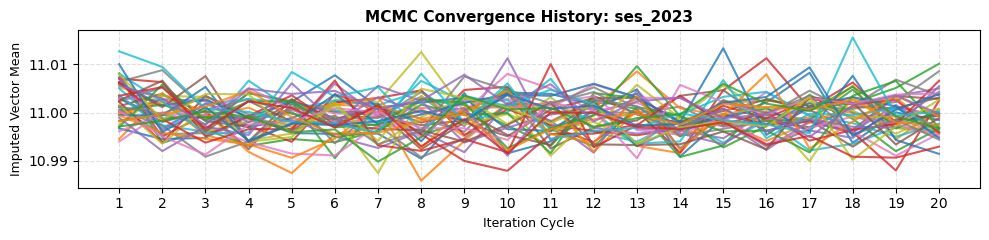

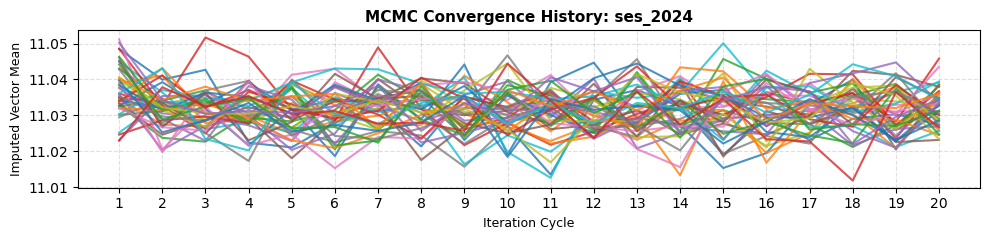

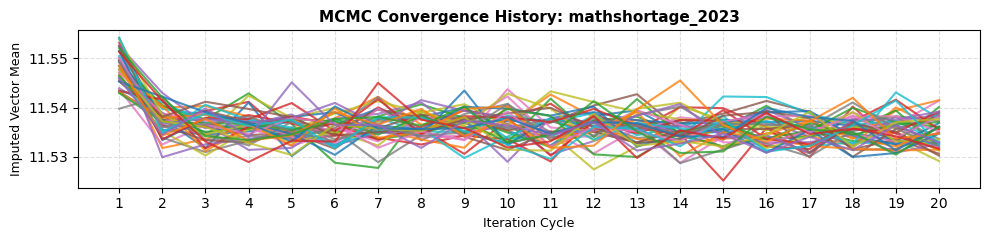

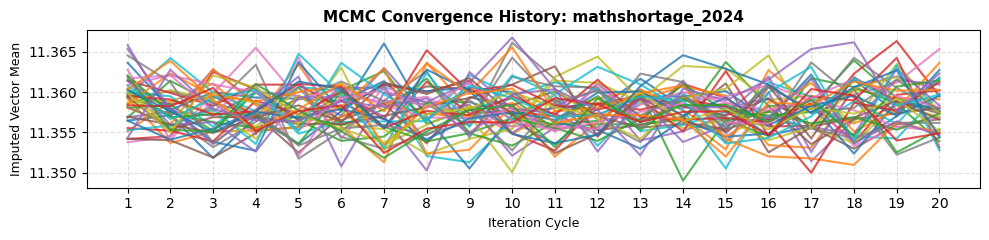

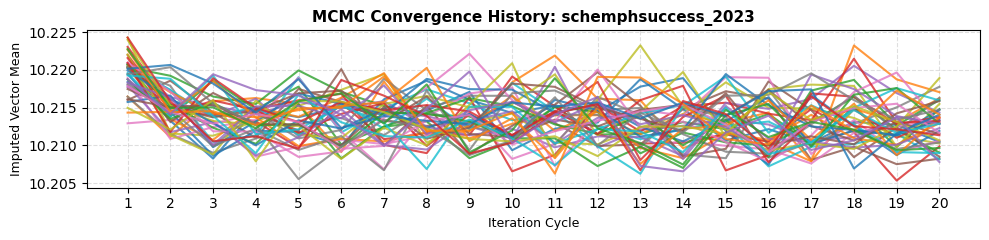

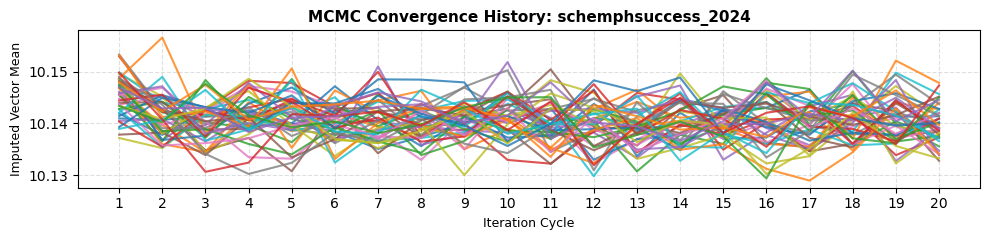

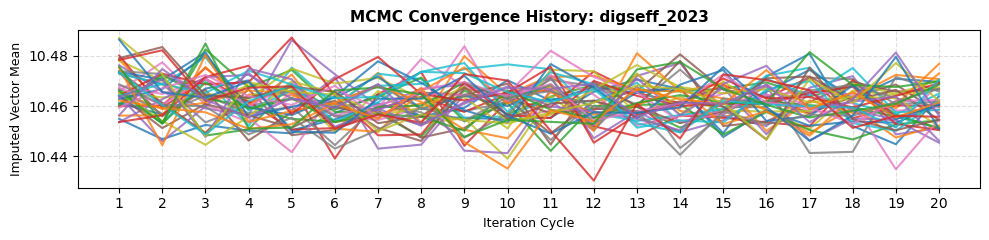

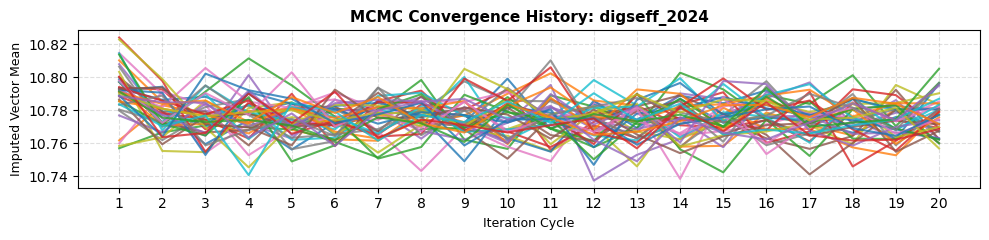

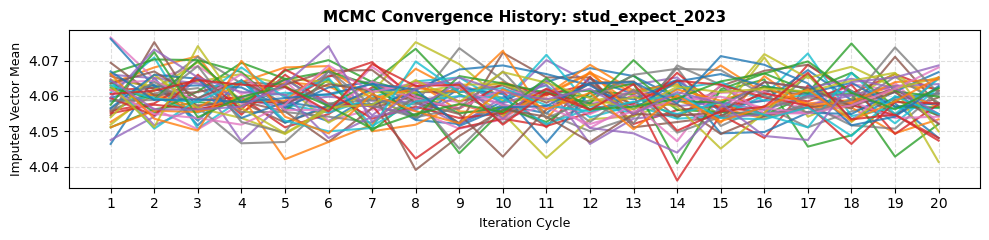

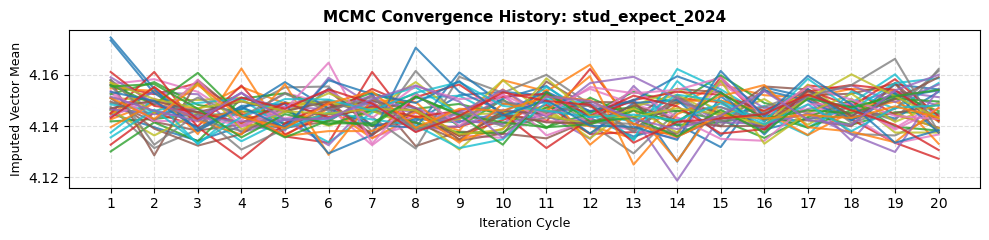

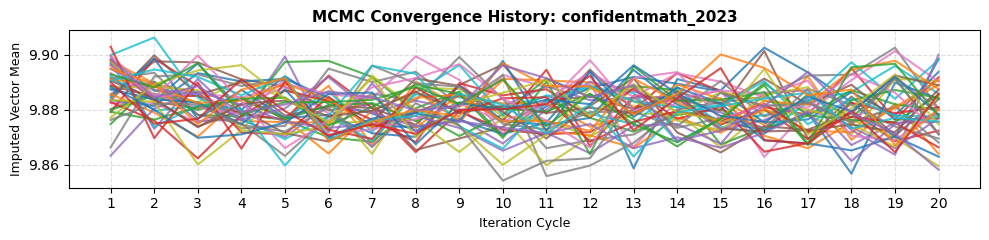

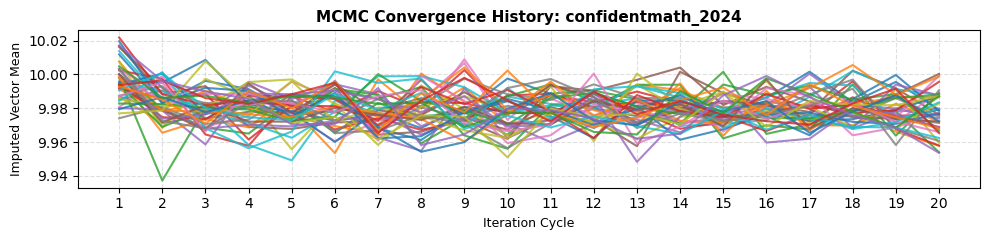

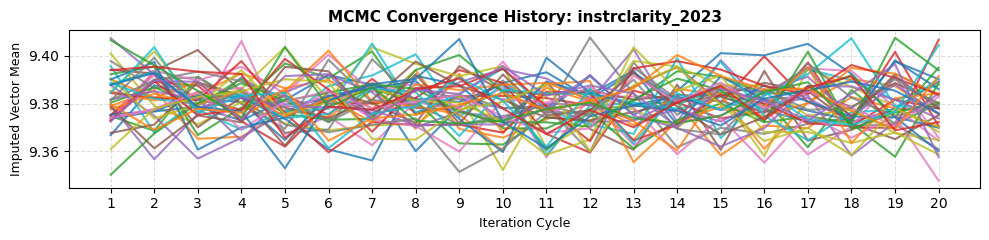

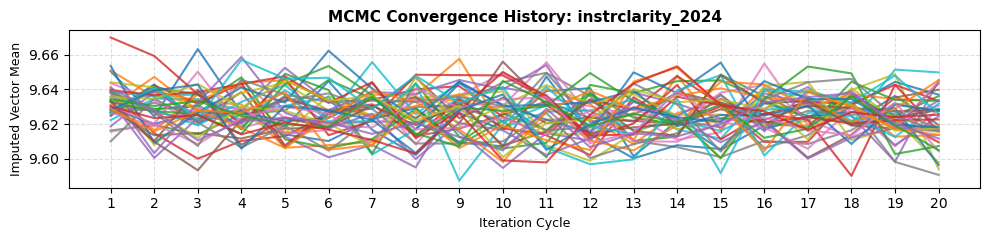


[Diagnostic 2/2] Compiling Distributional Plausibility Subplot Matrix...


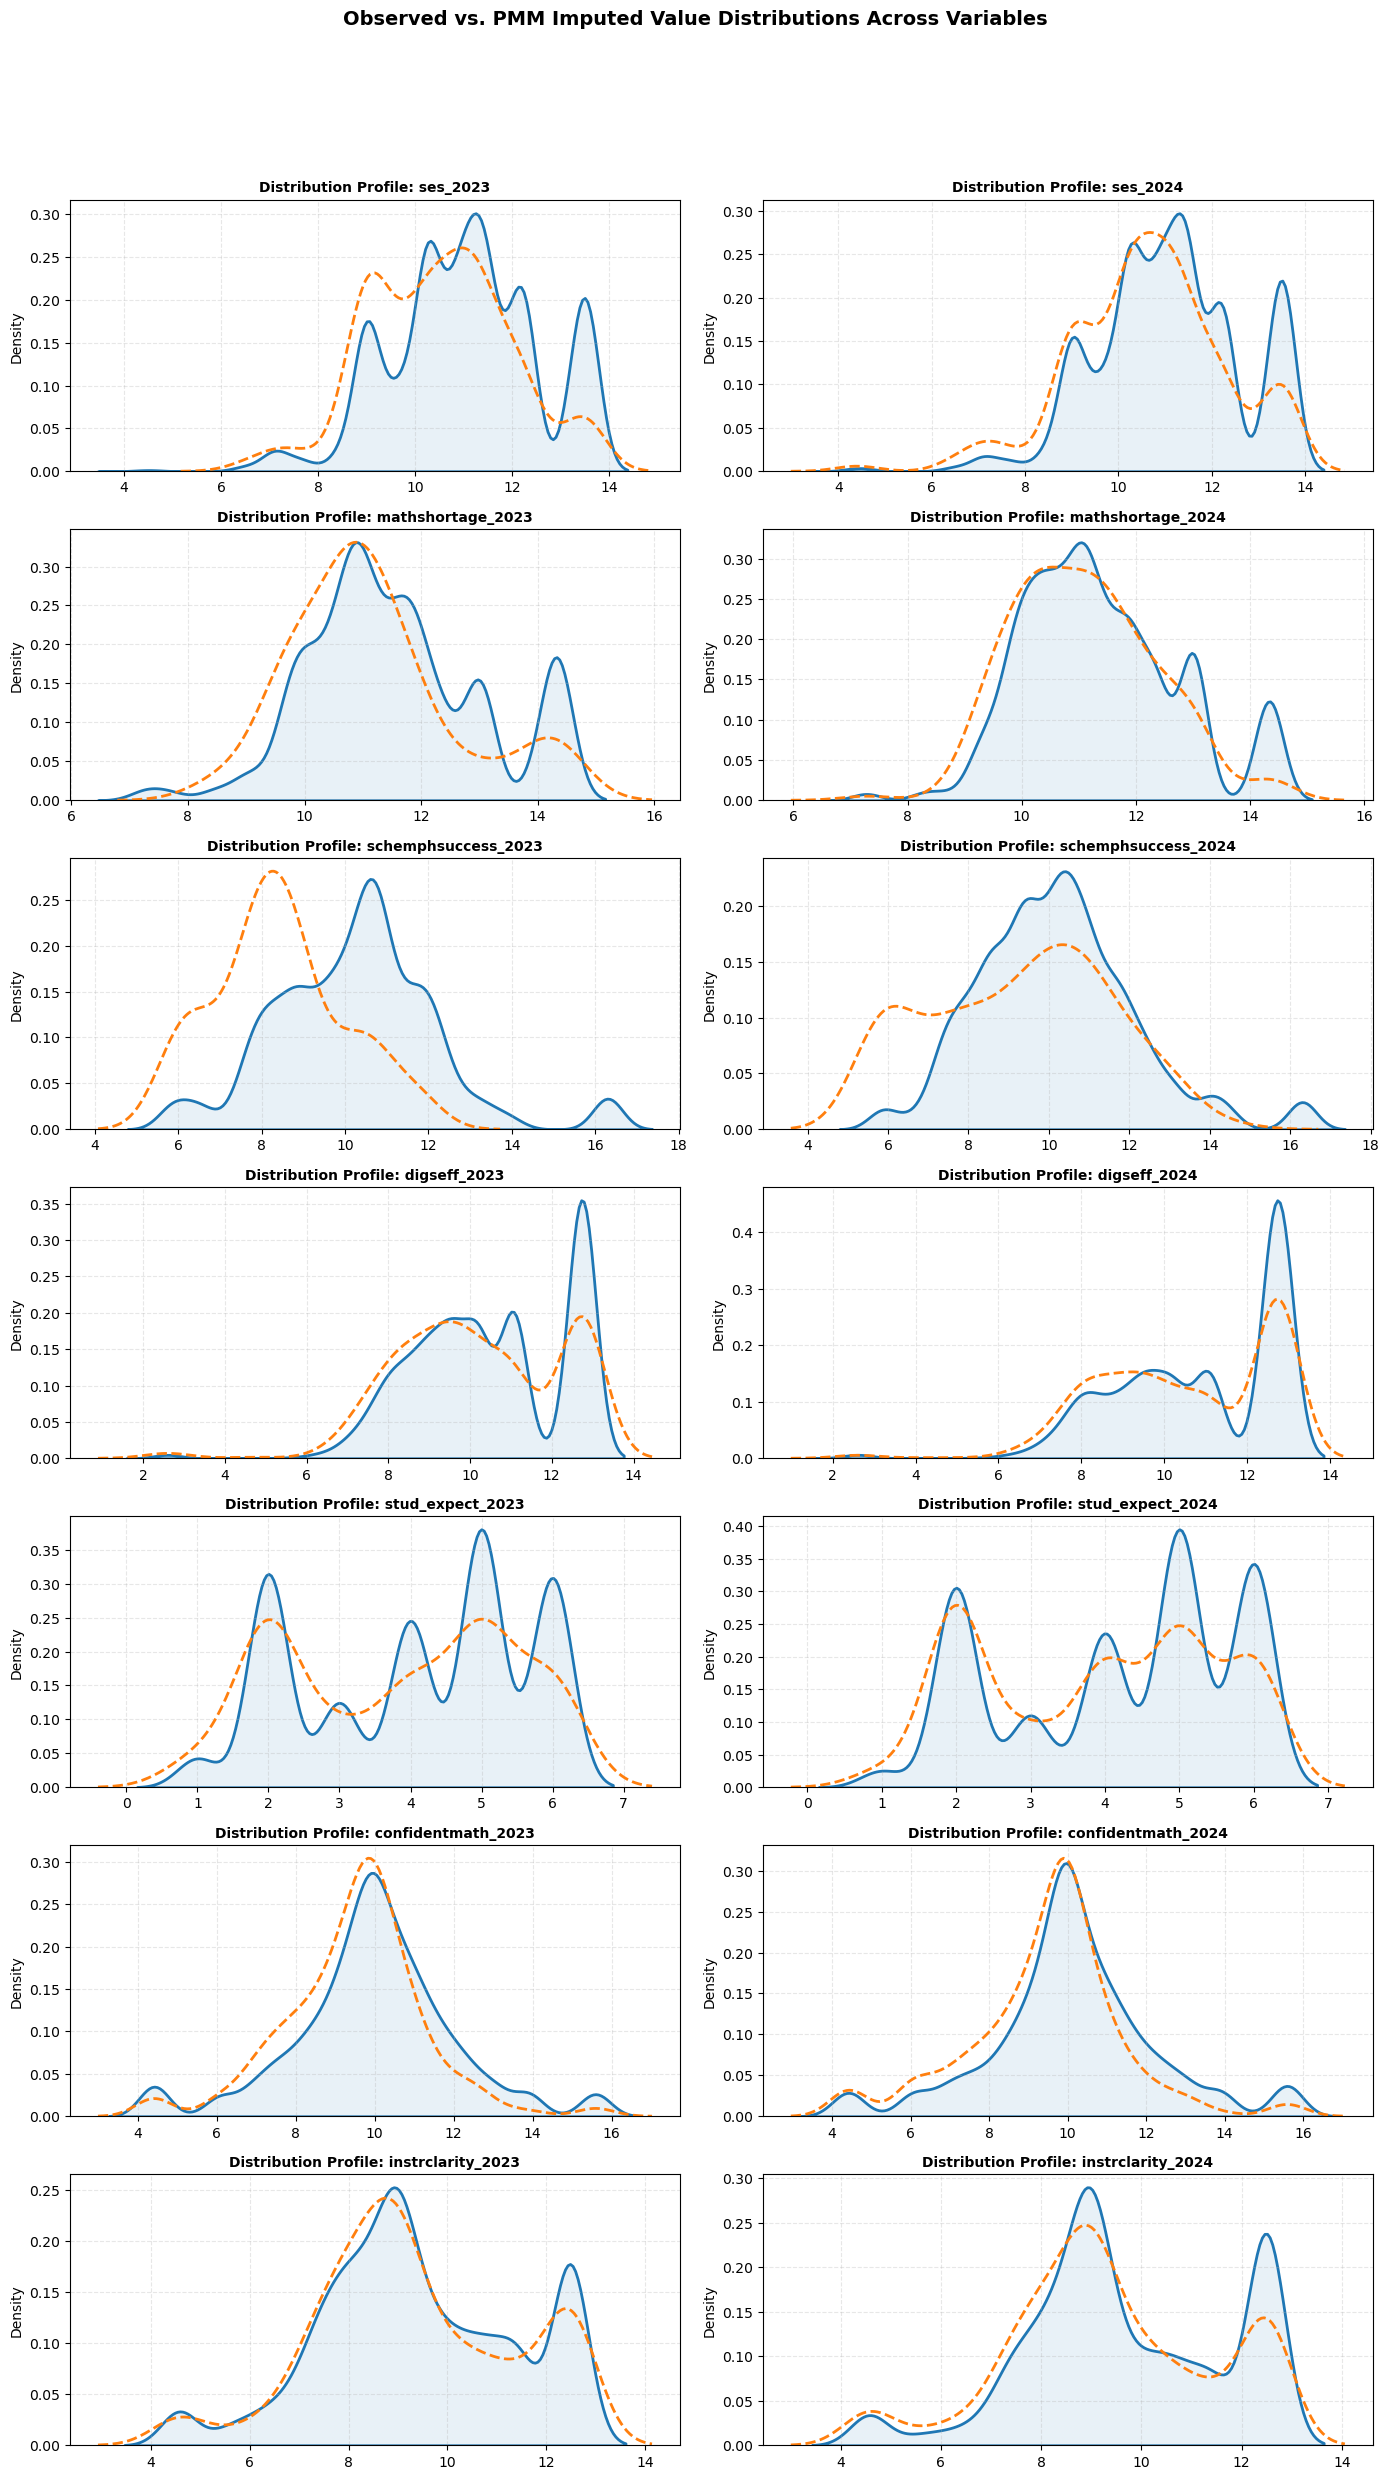

==================== Dataset: BEFORE IMPUTATION SURVEY MARGINS ====================
                     Raw Weighted Mean (Observed)
ses_2023                                11.015369
ses_2024                                 11.05774
mathshortage_2023                       11.574943
mathshortage_2024                       11.323225
schemphsuccess_2023                     10.229552
schemphsuccess_2024                     10.053725
digseff_2023                            10.441827
digseff_2024                            10.791798
stud_expect_2023                         4.065806
stud_expect_2024                         4.160152
confidentmath_2023                        9.97081
confidentmath_2024                      10.132259
instrclarity_2023                        9.495056
instrclarity_2024                        9.742754 

==================== Dataset: AFTER IMPUTATION POOLED SURVEY MARGINS ====================
                     Pooled Weighted Mean (Rubin Grand Average)
ses_2023  

In [5]:
# Final Imputation with Recommended minimum M (m_datasets=45)
print("\n\n" + "#"*20 + "FINAL IMPUTATION" + "#"*20)
imputed_dfs_sweden, trace_dataframe, diagnostic_table = mice_and_diagnostics(
    df=sweden_df, 
    imputed_cols=imputed_variables, 
    auxiliary_cols=auxiliary_vars, 
    m_datasets=45, 
    burnin=20,
    plot_diagnostics=True,
    knn=5, seed=1234, weight_var='TOTWGT',
    label="Dataset",
    #predictor_map=predictor_map
)

### An Illustrative Problem:
The `schemphsuccess_2023` observed-vs-imputed density plot shows a leftward shift, with the imputed distribution peaking around 8 versus the observed peak around 10.5–11, raising the question of whether this reflected a genuine subpopulation difference or a bias introduced by the imputation model.

In [6]:
# An example post-imputation diagnostics
predictors = [c for c in imputed_variables + auxiliary_vars if c != 'schemphsuccess_2023']
missing_mask = sweden_df['schemphsuccess_2023'].isna()

comparison = sweden_df.groupby(missing_mask)[predictors].mean().T
comparison.columns = ['Observed', 'Missing']
comparison['Diff'] = comparison['Missing'] - comparison['Observed']
print("****** Comparison Table\n", comparison)

# R^2 check
def check_r2(df, target, predictors):
    obs_mask = df[target].notna() & df[predictors].notna().all(axis=1)
    X_obs = df.loc[obs_mask, predictors].astype(float).values
    Y_obs = df.loc[obs_mask, target].astype(float).values

    n_obs = len(Y_obs)
    X_obs_w_int = np.hstack([np.ones((n_obs, 1)), X_obs])
    beta_hat = np.linalg.inv(X_obs_w_int.T @ X_obs_w_int) @ (X_obs_w_int.T @ Y_obs)
    residuals = Y_obs - (X_obs_w_int @ beta_hat)
    r2 = 1 - np.sum(residuals ** 2) / np.sum((Y_obs - Y_obs.mean()) ** 2)

    print(f"{target}: n_obs={n_obs}, predictors={len(predictors)}, R^2={r2:.4f}")
    return r2
print("\n****** R^2 Check")
schemph_predictors = [c for c in imputed_variables + auxiliary_vars if c != 'schemphsuccess_2023']
check_r2(sweden_df, 'schemphsuccess_2023', schemph_predictors)

****** Comparison Table
                       Observed     Missing       Diff
ses_2023             11.039569   10.916922  -0.122648
ses_2024             11.101589   10.680881  -0.420708
mathshortage_2023    11.548081         NaN        NaN
mathshortage_2024    11.379984   11.024582  -0.355402
schemphsuccess_2024  10.251222    7.453646  -2.797576
digseff_2023         10.491782    10.41103  -0.080752
digseff_2024         10.823211   10.553501  -0.269711
stud_expect_2023      4.075815    4.387931   0.312116
stud_expect_2024      4.202697     4.11215  -0.090547
confidentmath_2023    9.956938   10.223894   0.266956
confidentmath_2024   10.112596   10.086353  -0.026244
instrclarity_2023     9.381427   10.117279   0.735852
instrclarity_2024     9.681402    9.750533   0.069131
math1_2023           514.55688  507.722716  -6.834164
math1_2024           525.64528  513.712022 -11.933258
school_math_mean23   514.55688  507.722716  -6.834164
school_math_mean24   525.64528  513.712022 -11.933258

**

np.float64(0.6531509888464444)

**Inference:**  
The imputation model for `schemphsuccess_2023` performs well on both counts — the missing group differs meaningfully from the observed group on strongly related predictors (`schemphsuccess_2024`, `math1_2023/2024`), and the inclusive predictor set explains 65% of the variance in the target ($R²$ = **0.653**). The leftward-shifted imputed distribution therefore reflects a well-specified model correctly recovering a real subpopulation difference, not a weak model or matching artifact — `predictor_map` customization is justifiably not needed for this variable.

### Cited References: 

Rubin, B. D. (1987). Multiple imputation for nonresponse in surveys. John Wiley & Sons.  
  
van Buuren, S. (2018). *Flexible imputation of missing data* (2nd Ed.). Chapman and Hall/CRC. https://doi.org/10.1201/9780429492259     

von Hippel, P. T. (2018). How Many Imputations Do You Need? A Two-stage Calculation Using a Quadratic Rule. Sociological Methods & Research, 49(3), 699–718. https://doi.org/10.1177/0049124117747303   